In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels/val.cache
/kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels/train.cache
/kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels/test_offshore/000169.txt
/kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels/test_offshore/000159.txt
/kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels/test_offshore/000491.txt
/kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels/test_offshore/000539.txt
/kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels/test_offshore/000269.txt
/kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels/test_offshore/000441.txt
/kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels/test_offshore/000969.txt
/kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels/test_offshore/001021.txt
/kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels/test_offshore/000651.txt
/kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels/test_offshore/001139.txt
/kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels/test_offshore

In [1]:
!nvidia-smi

Sun Oct  4 09:32:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 4.8 MB/s eta 0:00:00


In [3]:
from pathlib import Path

# Find the dataset root: the folder that contains "images".
roots = [p.parent for p in Path("/kaggle/input").rglob("images") if p.is_dir()]
print(roots)

DATA_ROOT = roots[0]
for split in ["train", "val", "test", "test_inshore", "test_offshore"]:
    n_images = len(list((DATA_ROOT / "images" / split).glob("*.jpg")))
    n_labels = len(list((DATA_ROOT / "labels" / split).glob("*.txt")))
    print(f"{split}: {n_images} images, {n_labels} labels")

[PosixPath('/kaggle/input/datasets/wojciechdamian/ssdd-yolo')]
train: 835 images, 835 labels
val: 93 images, 93 labels
test: 232 images, 232 labels
test_inshore: 46 images, 46 labels
test_offshore: 186 images, 186 labels


In [4]:
yaml_text = f"""path: {DATA_ROOT}
train: images/train
val: images/val
test: images/test

names:
  0: ship
"""

yaml_path = Path("/kaggle/working/ssdd.yaml")
yaml_path.write_text(yaml_text)
print(yaml_path.read_text())

path: /kaggle/input/datasets/wojciechdamian/ssdd-yolo
train: images/train
val: images/val
test: images/test

names:
  0: ship



In [5]:
from ultralytics import YOLO

# Baseline: smallest YOLOv8 model, mostly default settings.
model = YOLO("yolov8n.pt")

results = model.train(
    data="/kaggle/working/ssdd.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,          # first GPU only
    patience=30,       # stop early if val mAP doesn't improve for 30 epochs
    seed=42,           # reproducible training
    name="baseline_yolov8n",
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/ssdd.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, fr

/usr/local/lib/python3.13/dist-packages/ray/train/_internal/session.py:683: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


      2/100       2.4G      1.497      1.494      1.111          8        640: 100% ━━━━━━━━━━━━ 53/53 9.1it/s 5.8s0.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 5.2it/s 0.6s0.4s
                   all         93        192      0.754      0.526      0.602      0.366

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100       2.4G      1.474      1.317      1.135          8        640: 100% ━━━━━━━━━━━━ 53/53 9.3it/s 5.7s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 5.4it/s 0.6s0.4s
                   all         93        192      0.733      0.682      0.698      0.432

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/100       2.4G      1.458      1.157      1.097         16        640: 100% ━━━━━━━━━━━━ 53/53 9.5it/s 5.6s0.2ss
                 Class     Images  Instance

In [6]:
!cd /kaggle/working && zip -r -q baseline_yolov8n.zip runs/detect/baseline_yolov8n

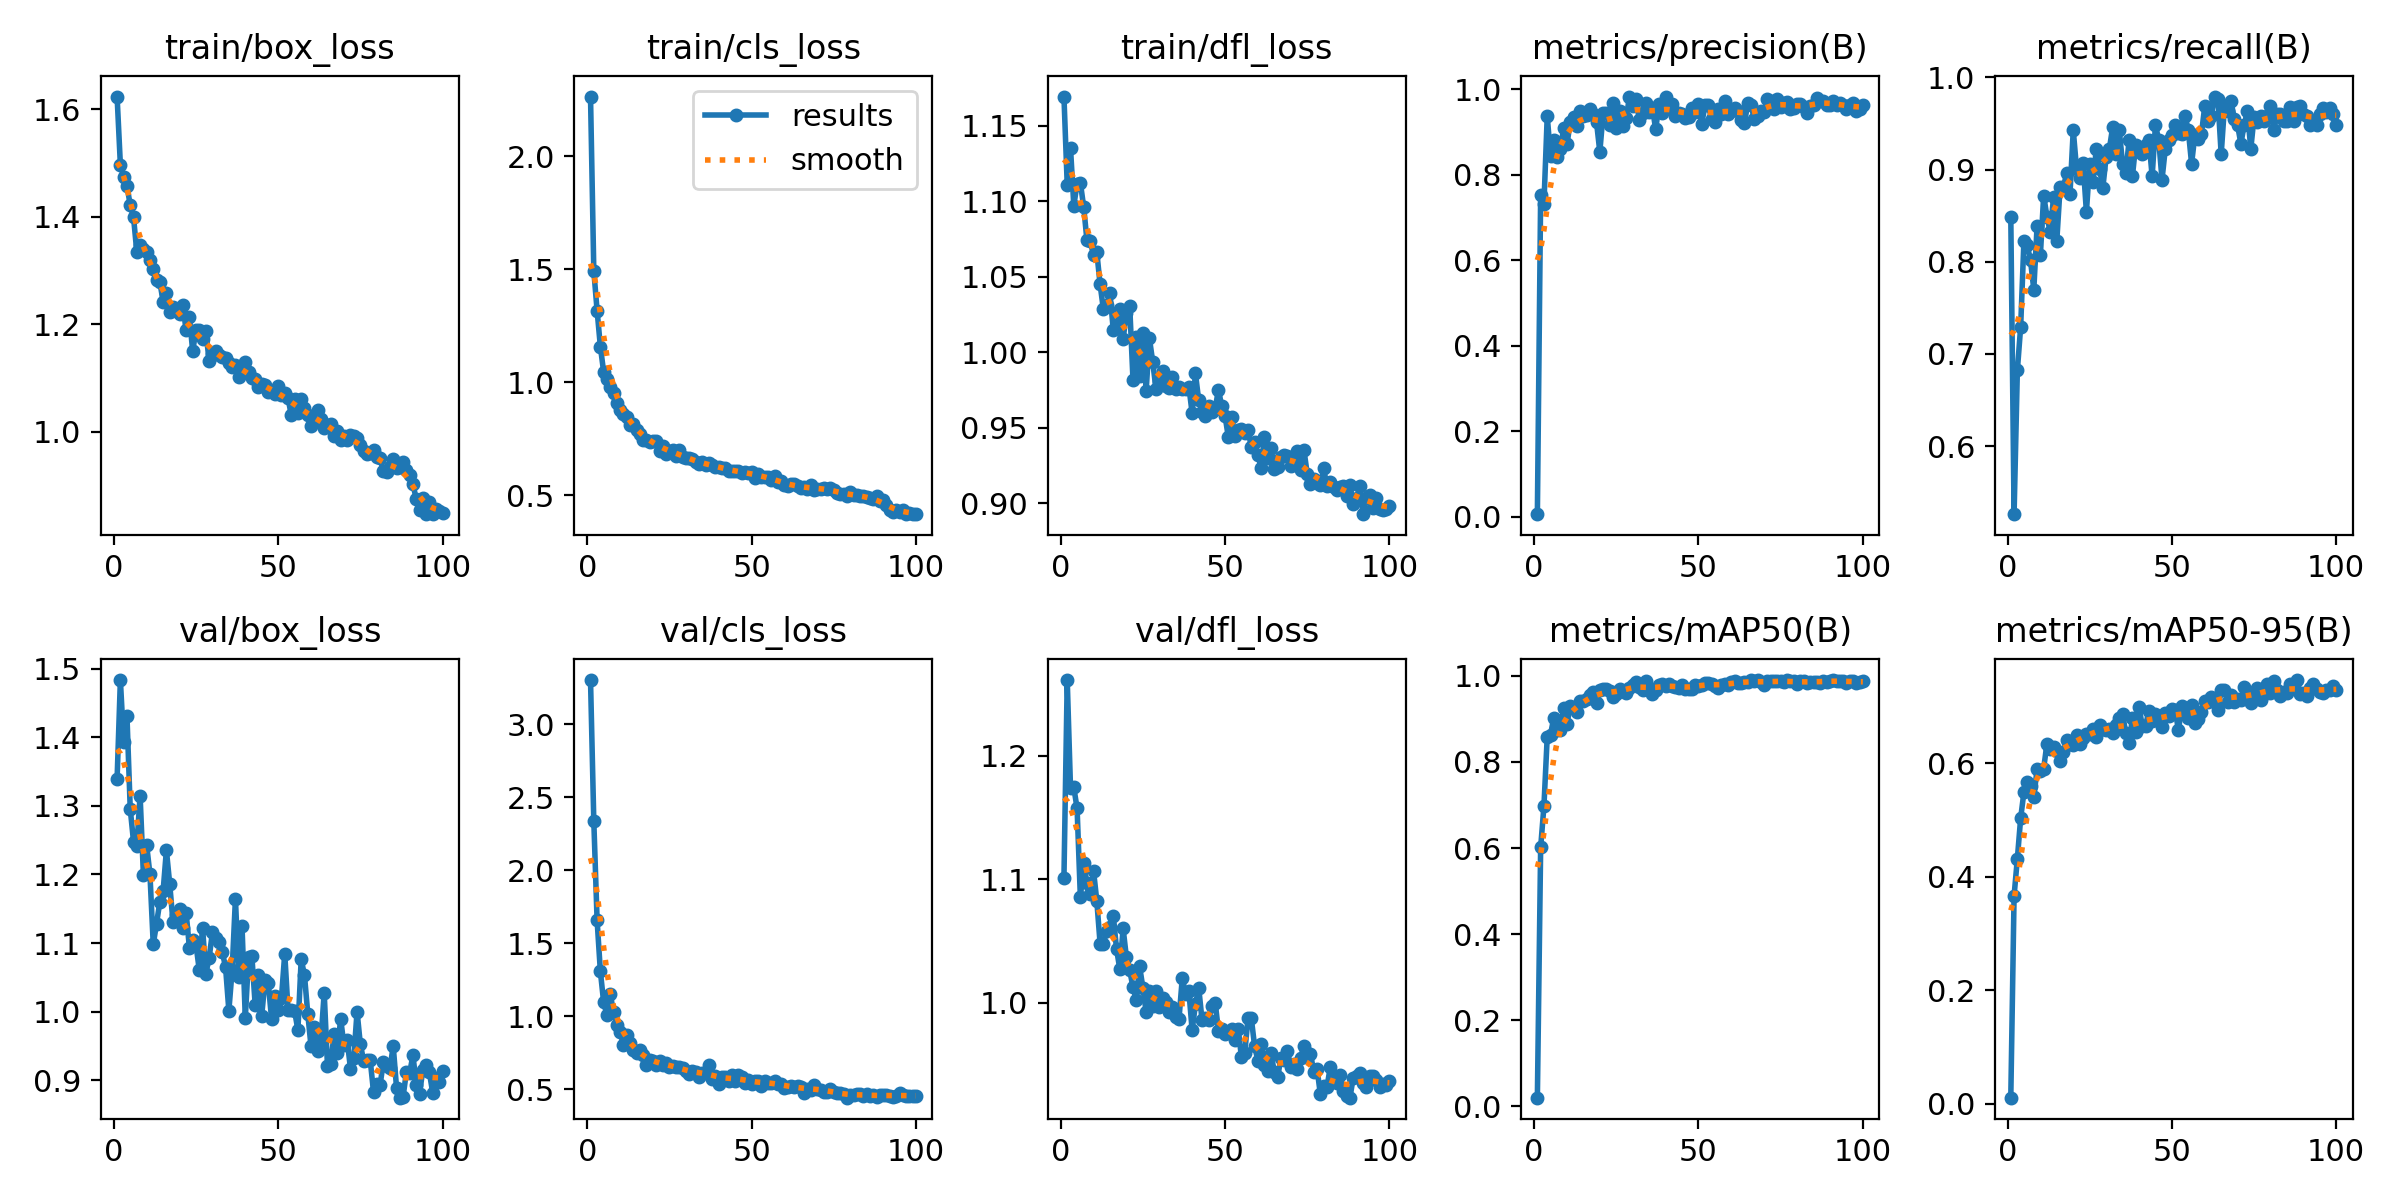

In [7]:
from IPython.display import Image, display

run_dir = "/kaggle/working/runs/detect/baseline_yolov8n"
display(Image(filename=f"{run_dir}/results.png"))

In [8]:
# Evaluation configs: in each one "val" points to a different test subset.
eval_sets = ["test", "test_inshore", "test_offshore"]

for name in eval_sets:
    yaml_text = f"""path: {DATA_ROOT}
train: images/train
val: images/{name}

names:
  0: ship
"""
    Path(f"/kaggle/working/ssdd_{name}.yaml").write_text(yaml_text)

print(list(Path("/kaggle/working").glob("ssdd_*.yaml")))

[PosixPath('/kaggle/working/ssdd_test_inshore.yaml'), PosixPath('/kaggle/working/ssdd_test.yaml'), PosixPath('/kaggle/working/ssdd_test_offshore.yaml')]


In [9]:
from ultralytics import YOLO

run_dir = "/kaggle/working/runs/detect/baseline_yolov8n"
model = YOLO(f"{run_dir}/weights/best.pt")

results = {}
for name in eval_sets:
    metrics = model.val(
        data=f"/kaggle/working/ssdd_{name}.yaml",
        imgsz=640,
        batch=16,
        device=0,
        name=f"baseline_eval_{name}",
    )
    results[name] = metrics

# Summary table
print(f"\n{'split':<15}{'P':>8}{'R':>8}{'mAP50':>8}{'mAP50-95':>10}")
for name, m in results.items():
    print(f"{name:<15}{m.box.mp:>8.3f}{m.box.mr:>8.3f}{m.box.map50:>8.3f}{m.box.map:>10.3f}")

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 5.2±4.4 MB/s, size: 40.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels/test... 232 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 232/232 138.8it/s 1.7s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/wojciechdamian/ssdd-yolo/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 5.6it/s 2.7s0.1s
                   all        232        546      0.972      0.956       0.99      0.711
Speed: 1.3ms preprocess, 4.3ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /k

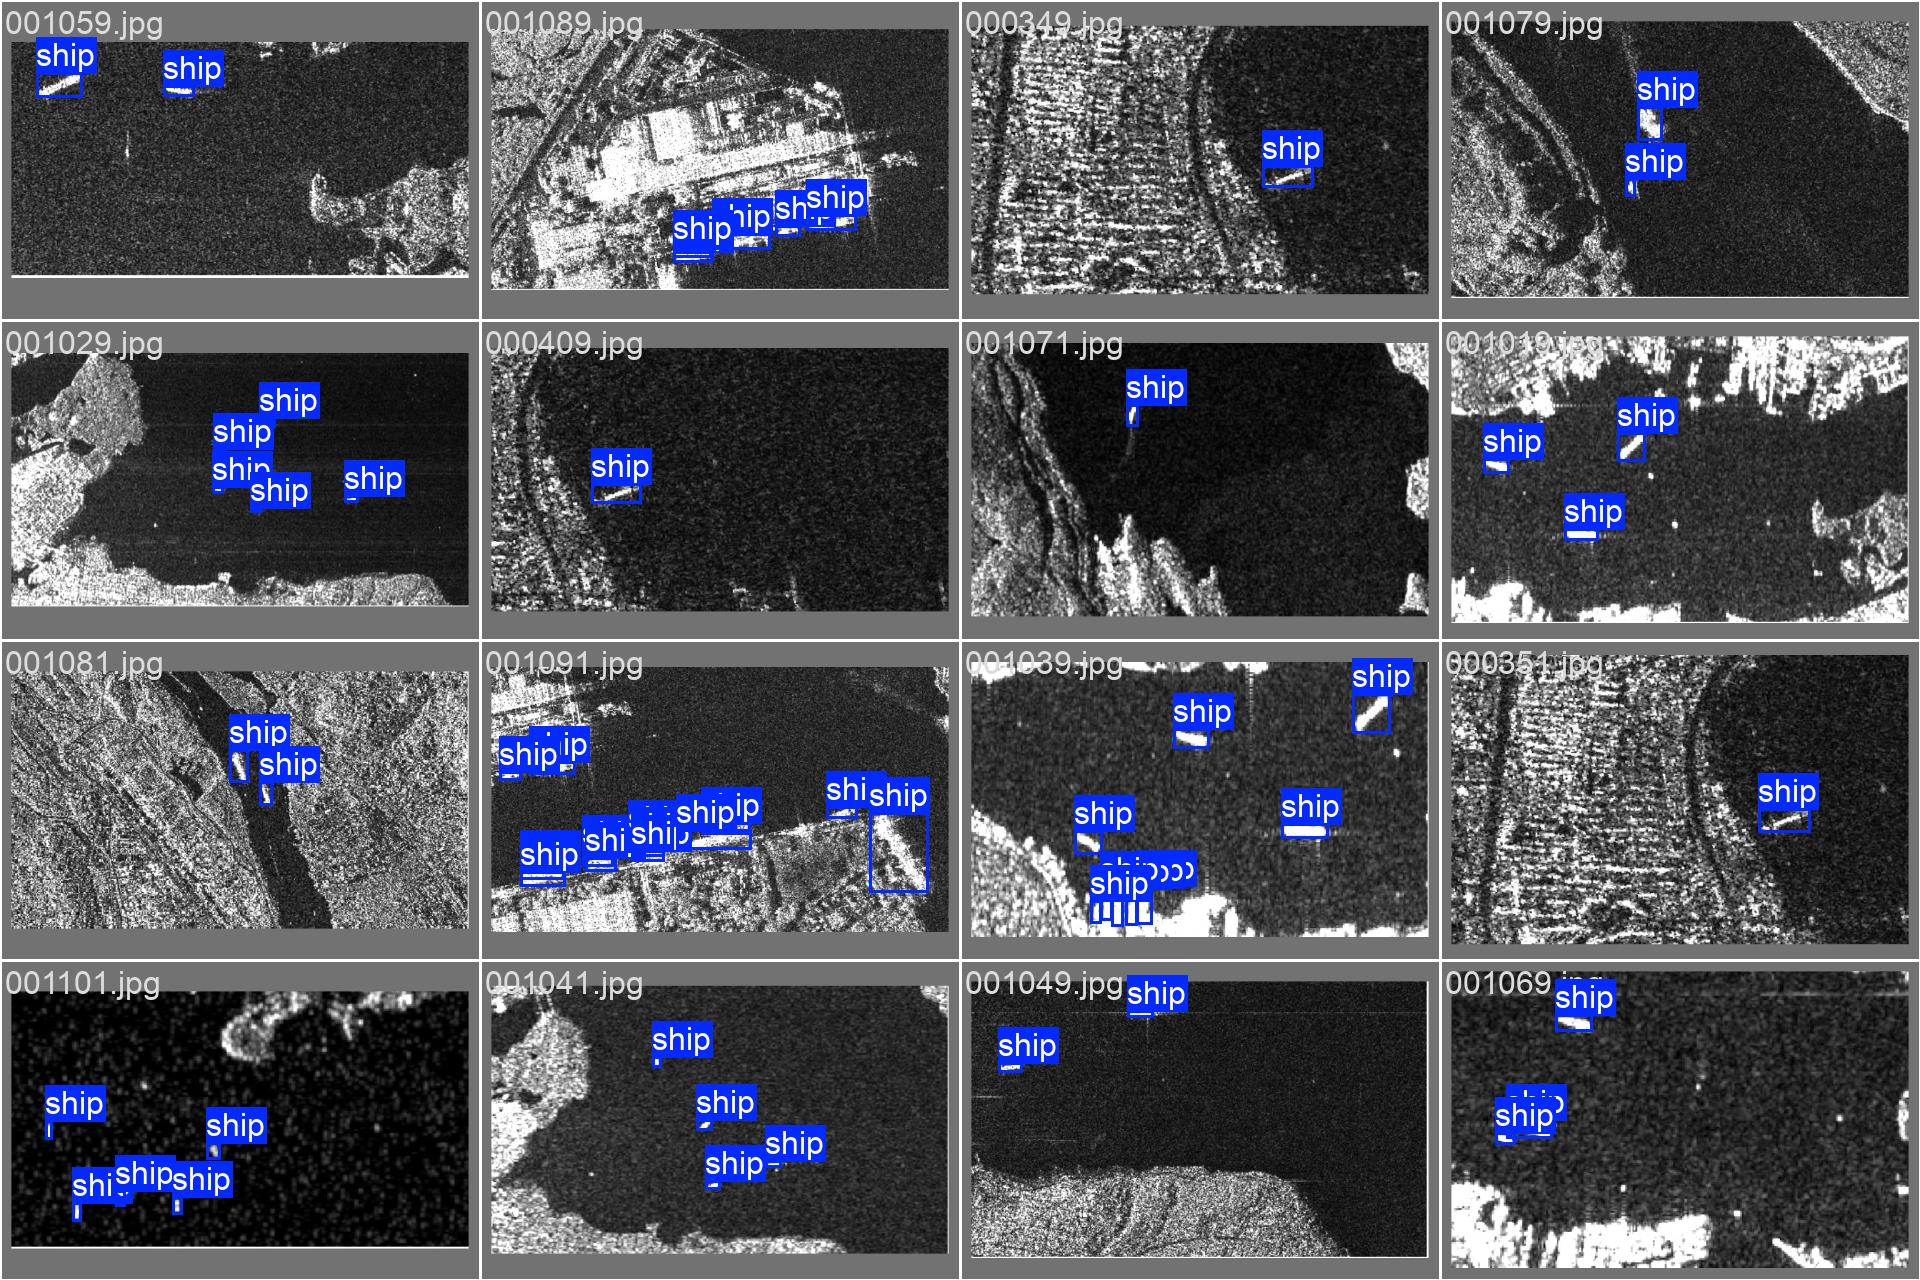

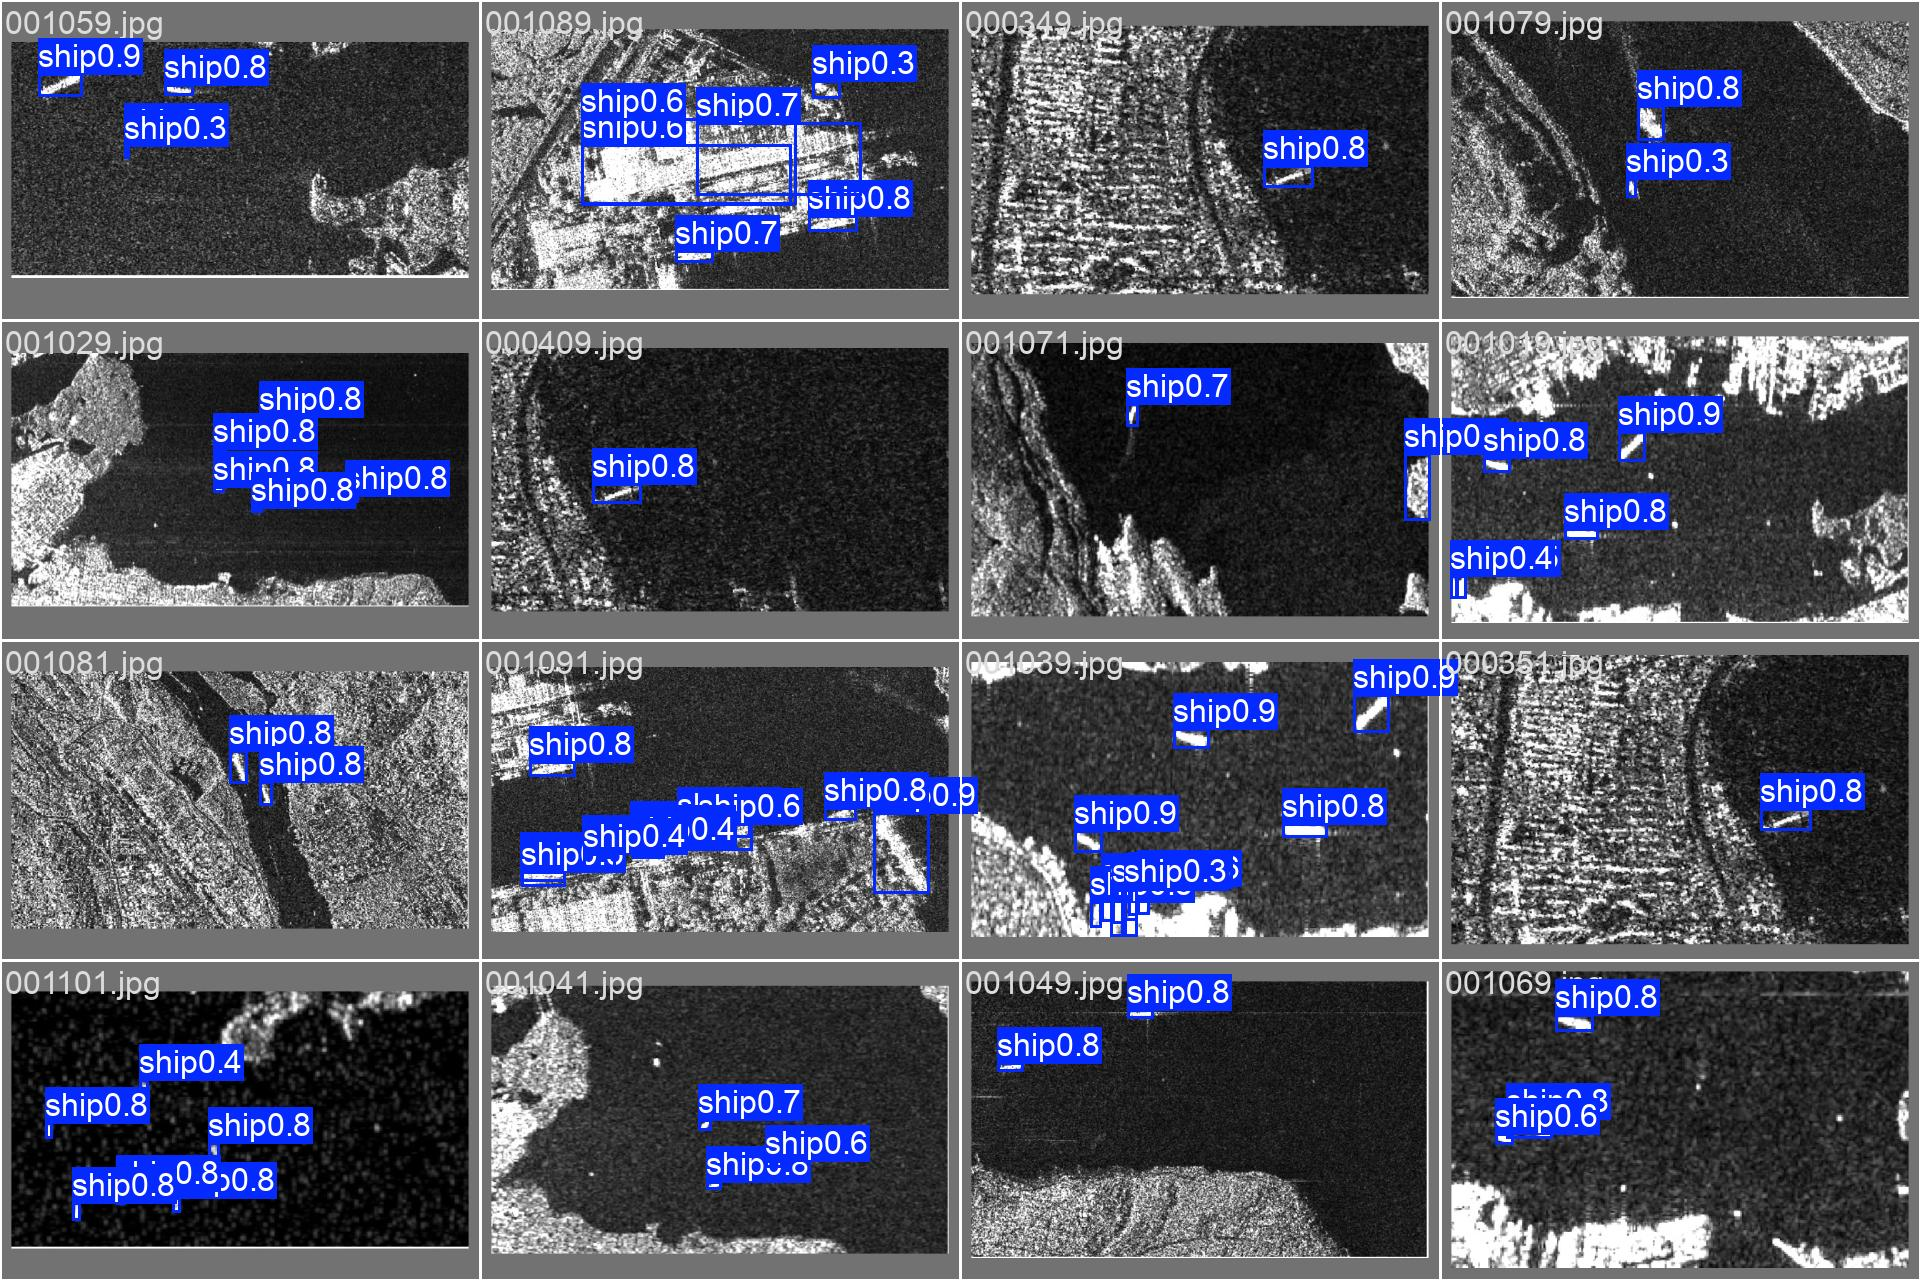

In [10]:
eval_dir = "/kaggle/working/runs/detect/baseline_eval_test_inshore"
display(Image(filename=f"{eval_dir}/val_batch0_labels.jpg"))
display(Image(filename=f"{eval_dir}/val_batch0_pred.jpg"))

In [11]:
!cd /kaggle/working && zip -r -q baseline_eval.zip runs/detect/baseline_eval_*